Wygenerowano: 1200 koncertow

  CZESC 1 — EKSPLORACJA

  Rozmiar:  1200 koncertow x 11 kolumn

  Pierwsze wiersze:
   event_id       data    miasto  latitude  longitude    gatunek typ_obiektu  pojemnosc  bilety_sprzedane  cena_biletu_pln  przychod_pln
0     50001 2024-04-12    Poznan   52.4064    16.9252    hip-hop        klub        410               316            170.0         53720
1     50002 2025-03-11    Gdansk   54.3520    18.6466       folk       arena       5799              2512            130.0        326560
2     50003 2024-09-27  Warszawa   52.2297    21.0122  classical        klub        634               414            100.0         41400

  Typy danych:
event_id                     int64
data                datetime64[us]
miasto                         str
latitude                   float64
longitude                  float64
gatunek                        str
typ_obiektu                    str
pojemnosc                    int64
bilety_sprzedane             int64
cena_b

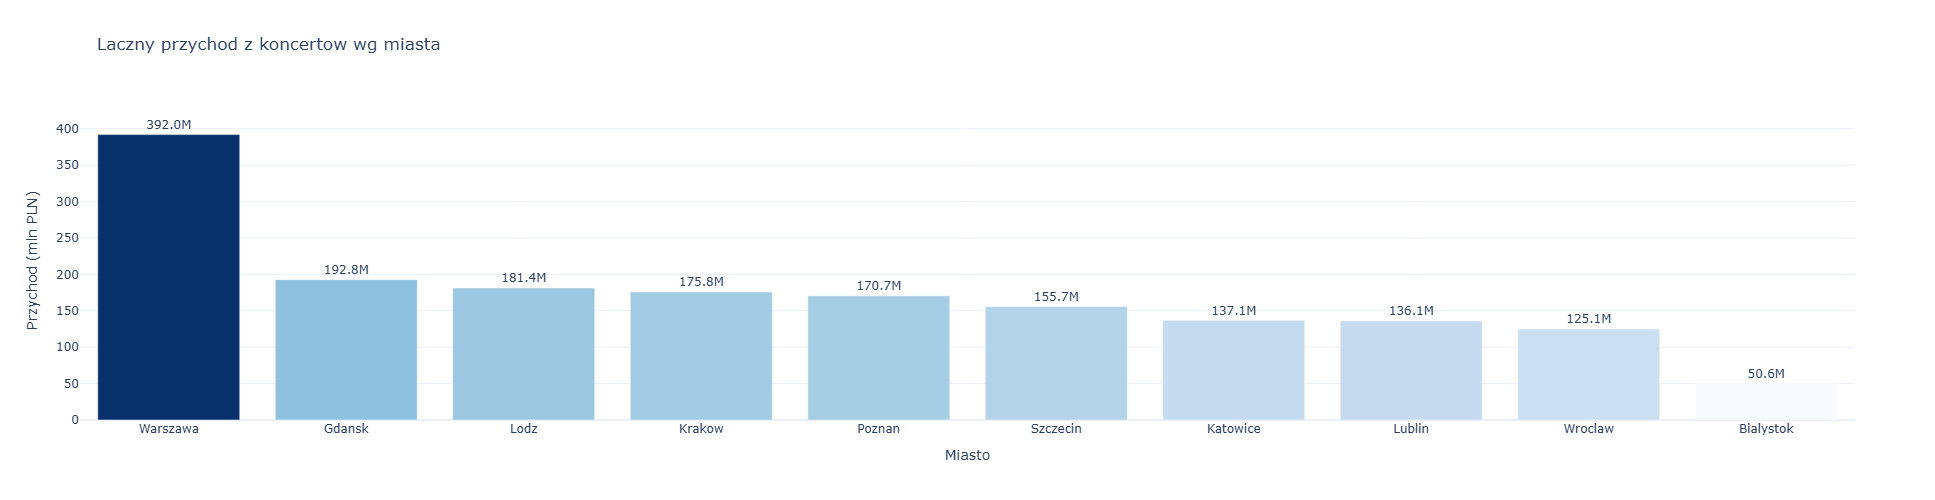

  Wykres 2: przychod wg miasta — gotowy


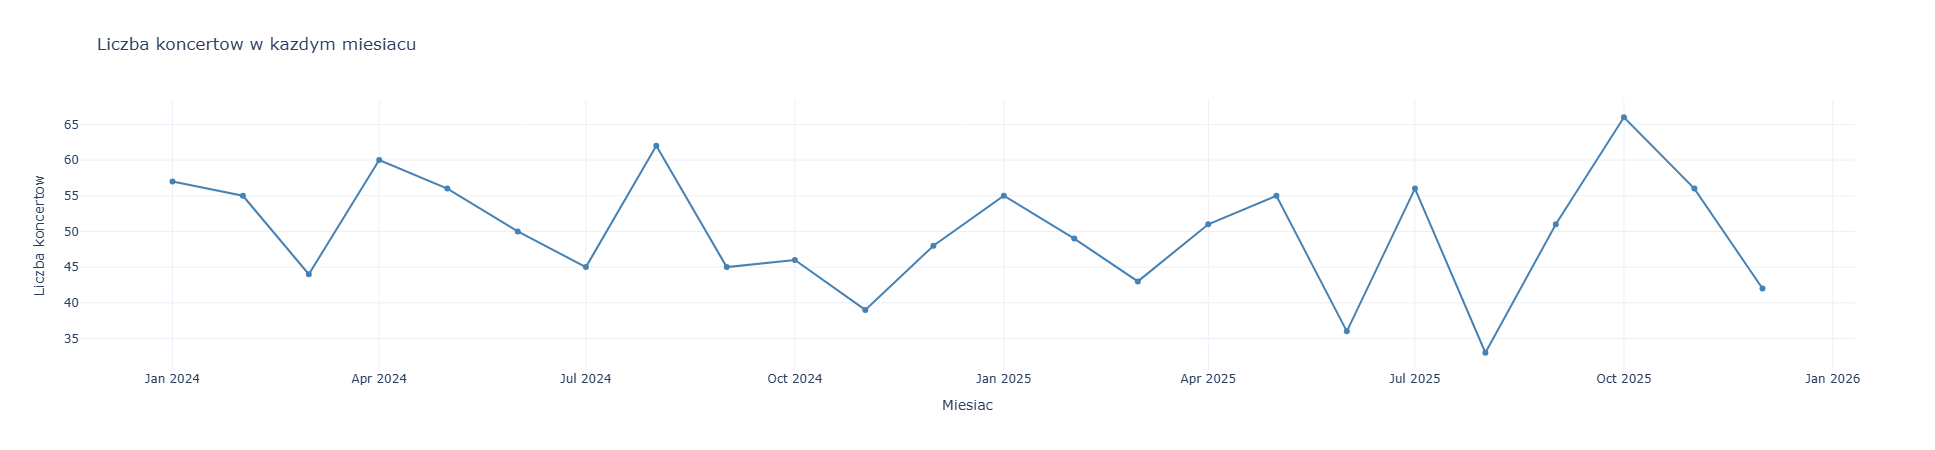

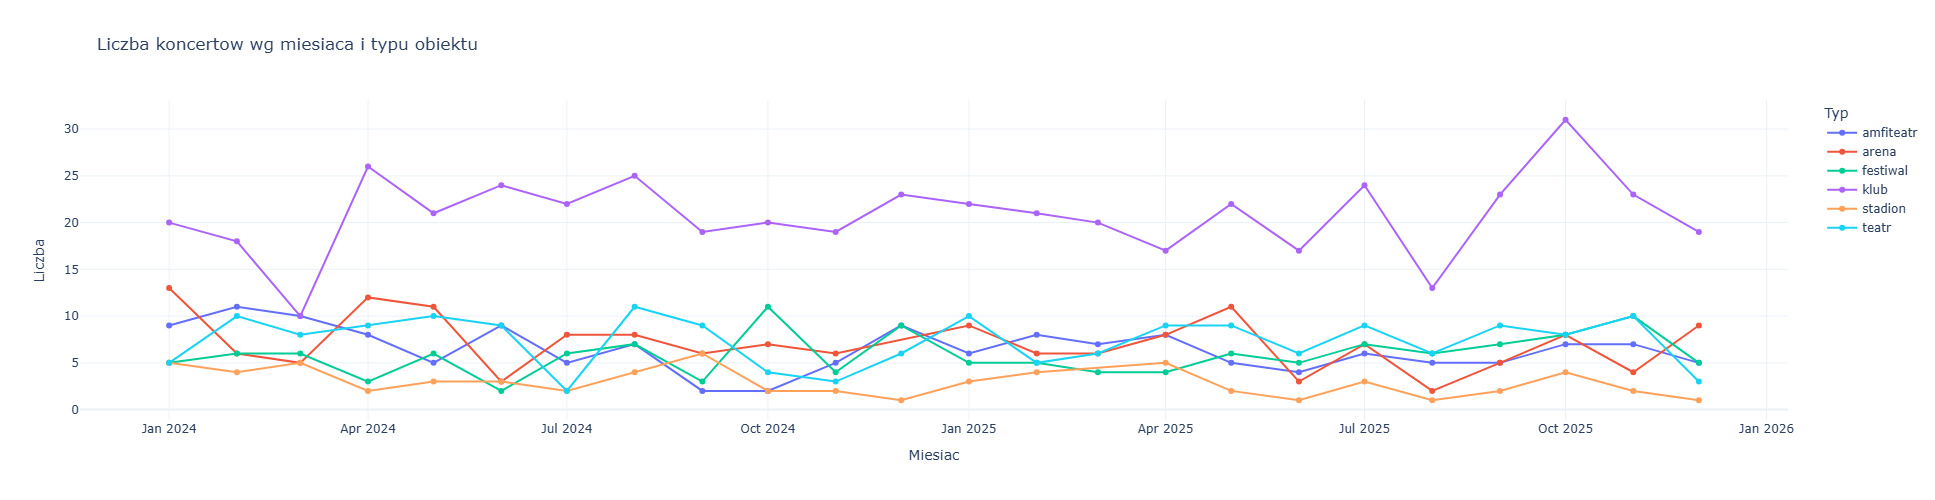

  Wykresy 3a i 3b: szeregi czasowe — gotowe


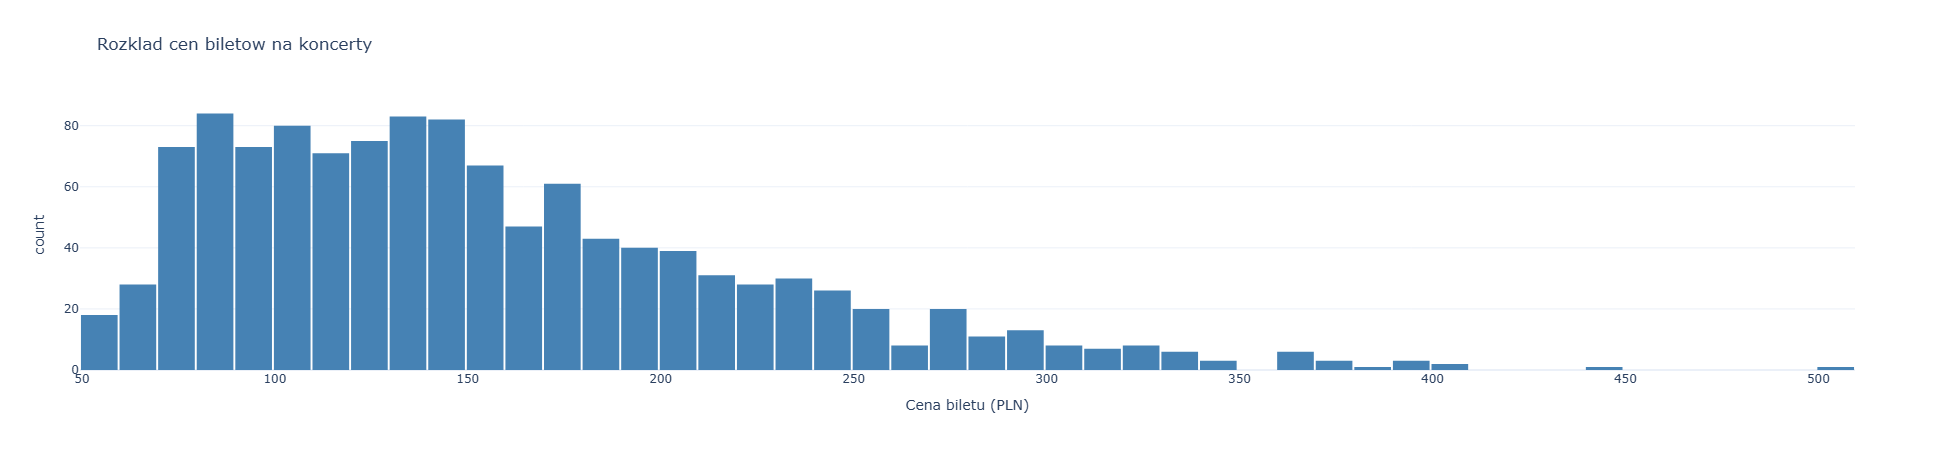

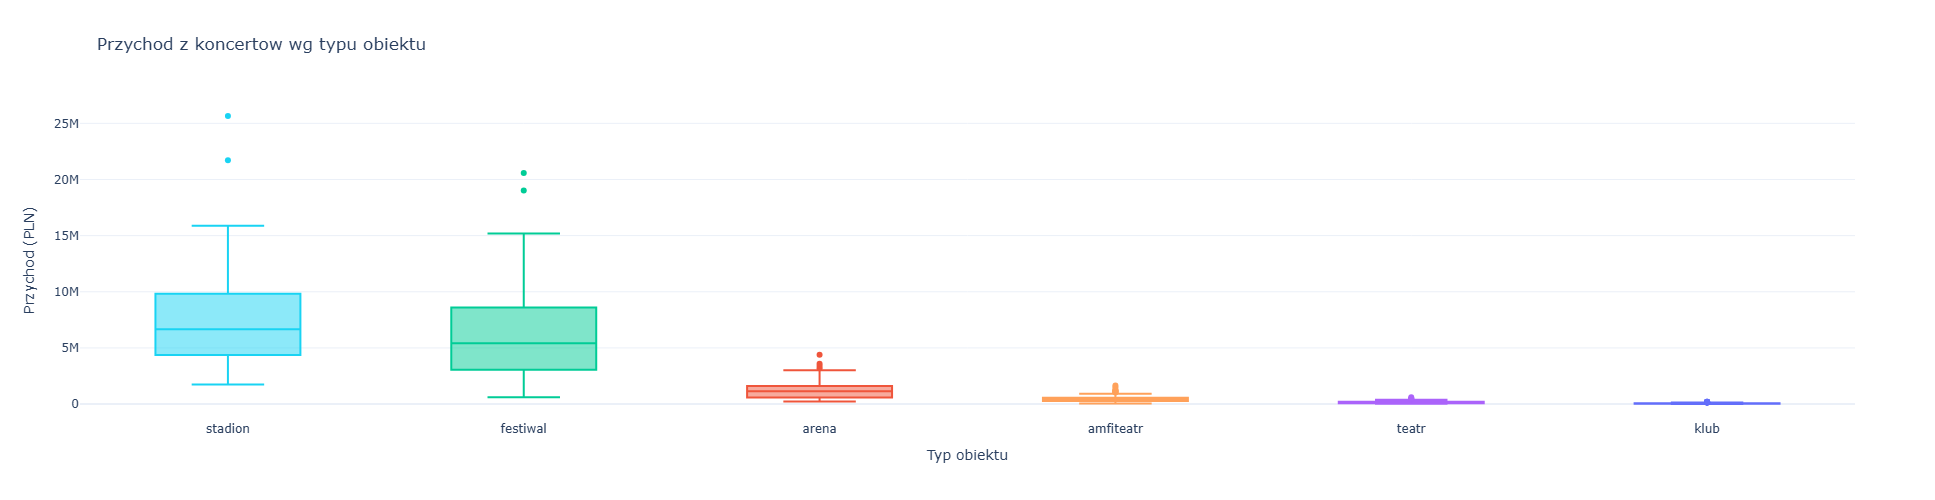


  Typ obiektu z najwyzszym medianym przychodem: stadion
  Wykresy 4a i 4b: histogram i boxplot — gotowe


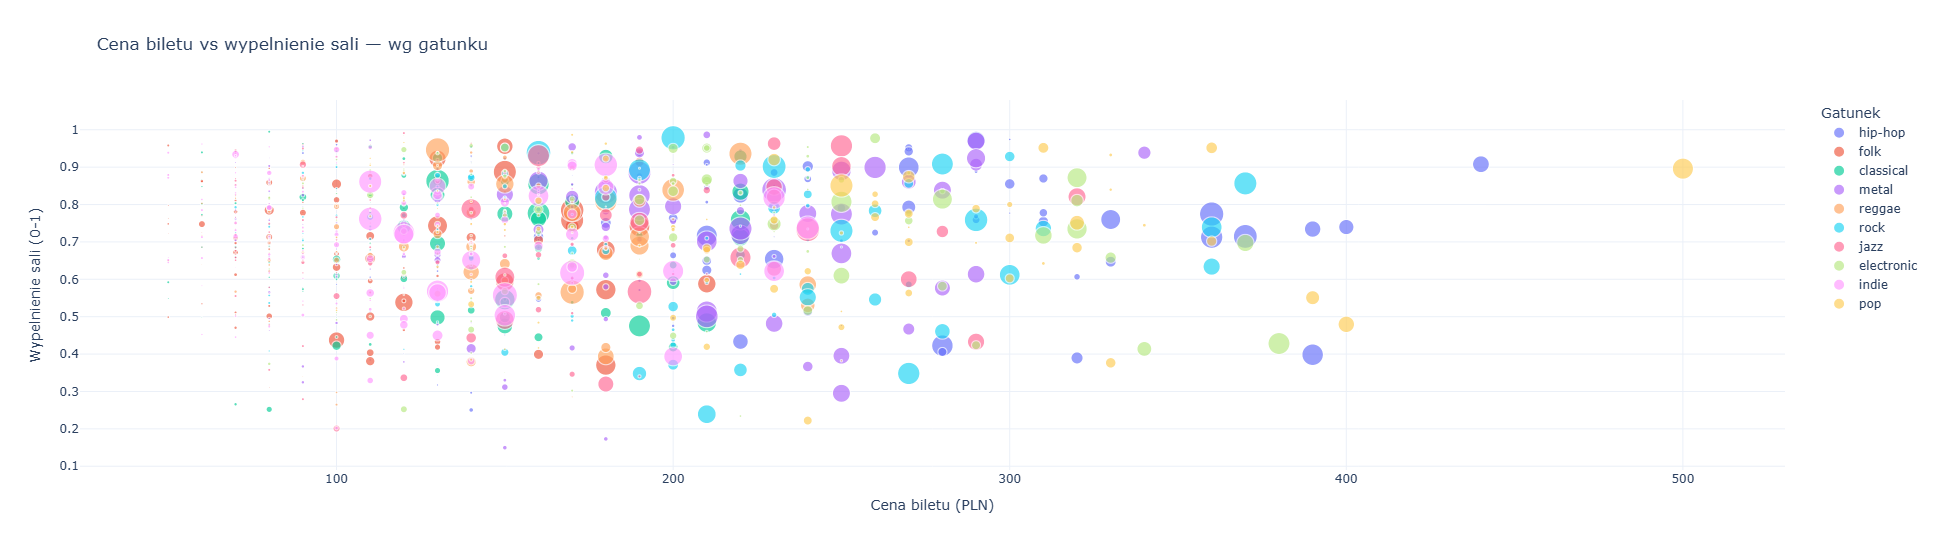


  Korelacja cena vs wypelnienie: 0.009
  (blisko 0 = brak silnej zaleznosci liniowej)
  Wykres 5: scatter — gotowy


C:\Users\Admin\AppData\Local\Temp\ipykernel_39288\970363435.py:289: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig6 = px.scatter_mapbox(


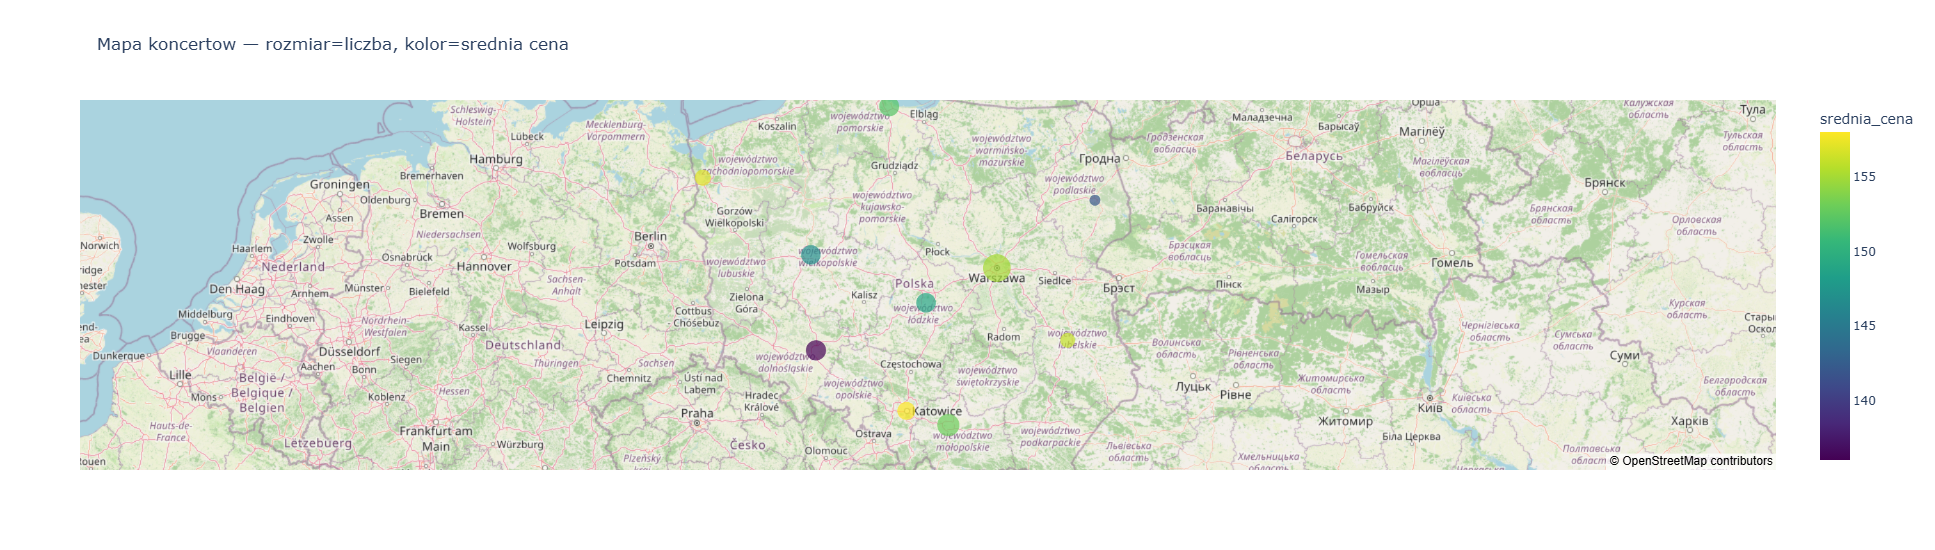

  Wykres 6: mapa — gotowy


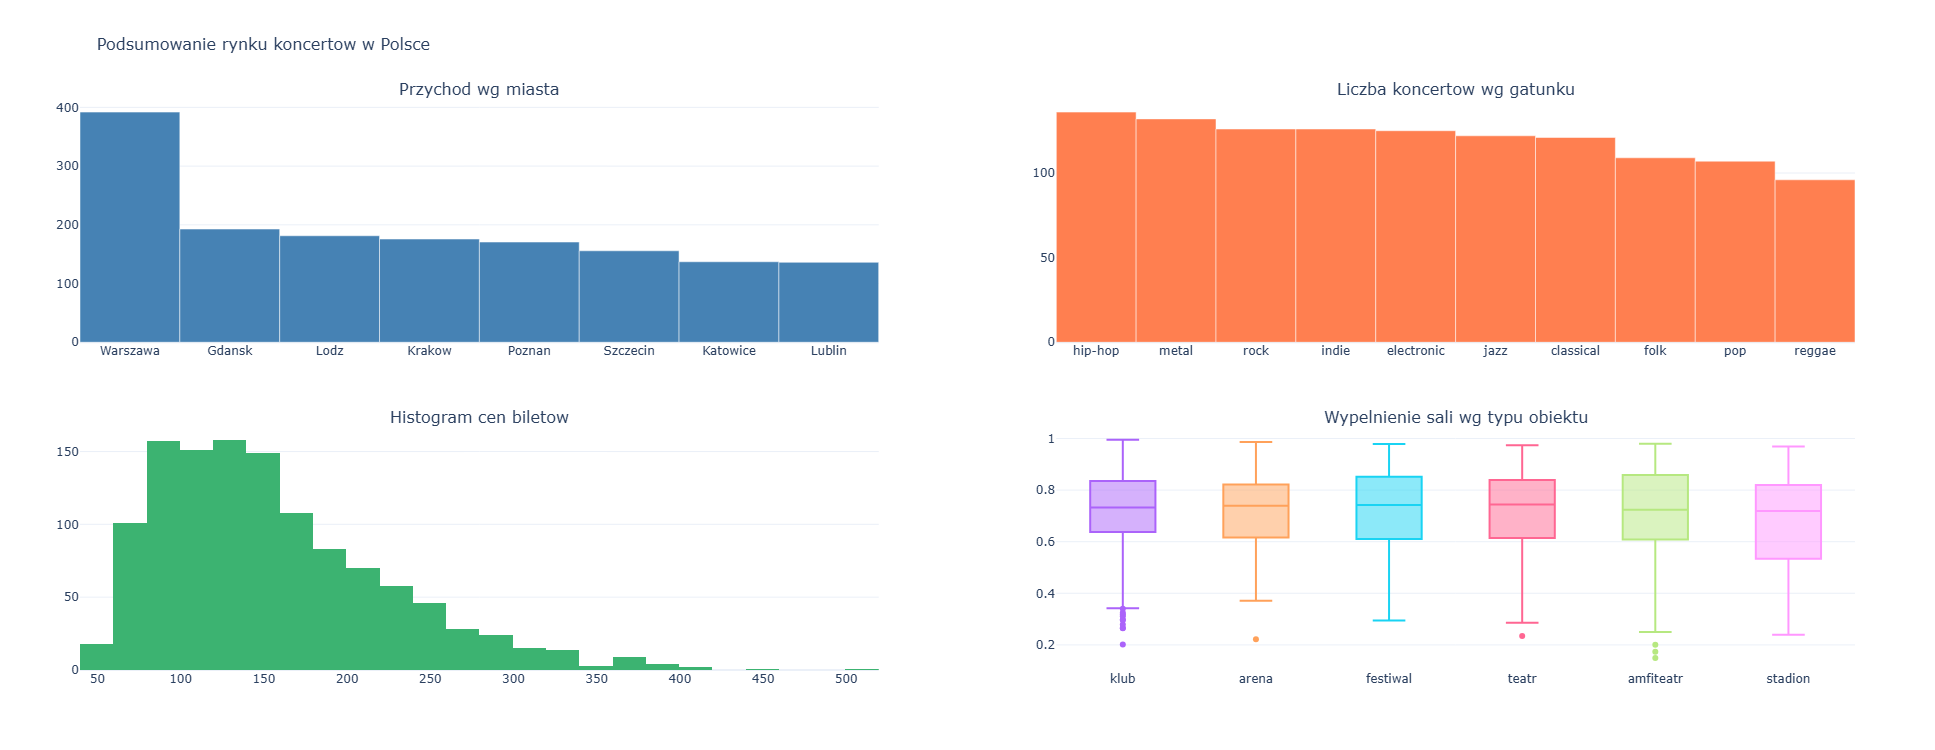

  Wykres 7: subploty 2x2 — gotowy

  CZESC 8 — WNIOSKI

  1. WARSZAWA dominuje rynek koncertowy
     Laczny przychod: 392.0 mln PLN — zdecydowanie
     wiecej niz inne miasta. Wynika to z najwiekszej
     populacji i infrastruktury koncertowej.

  2. STADIONY i FESTIWALE generuja najwyzsze przychody
     Choc koncertow klubowych jest wiecej (40% wszystkich),
     to stadiony i festiwale dzieki ogromnej pojemnosci
     i wyzszym cenom biletow dominuja pod wzgledem obrotu.

  3. GATUNEK "hip-hop" to najpopularniejszy format
     Najwiecej koncertow organizowanych jest w tym gatunku,
     co sugeruje najwyzsza dostepnosc artystow i popyt.

  4. BRAK WYRAZNEJ SEZONOWOSCI w danych 2-letnich
     Liczba koncertow jest wzglednie rowna przez caly rok,
     z niewielkimi wahaniami. Widoczny jest lekki wzrost
     w miesiacach wiosennych i letnich (maj-sierpien).

  5. WYPELNIENIE SALI srednio 71%
     Wiekszosc koncertow jest dobrze wypelnionych.
     Nie ma silnej korelacji miedzy cena biletu 

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta

# ============================================================
# KROK 0 — Generowanie danych (uruchom tylko raz)
# ============================================================

np.random.seed(42)
n = 1200

# Slownik miast: nazwa → (lat, lon, waga_popularnosci)
miasta = {
    "Warszawa":  (52.2297, 21.0122, 1.00),
    "Krakow":    (50.0647, 19.9450, 0.75),
    "Wroclaw":   (51.1079, 17.0385, 0.65),
    "Poznan":    (52.4064, 16.9252, 0.55),
    "Gdansk":    (54.3520, 18.6466, 0.55),
    "Lodz":      (51.7592, 19.4560, 0.50),
    "Katowice":  (50.2649, 19.0238, 0.45),
    "Lublin":    (51.2465, 22.5684, 0.30),
    "Bialystok": (53.1325, 23.1688, 0.25),
    "Szczecin":  (53.4285, 14.5528, 0.35),
}

gatunki = ["rock", "pop", "hip-hop", "electronic", "jazz",
           "classical", "folk", "metal", "indie", "reggae"]

typy_obiektow = ["klub", "arena", "stadion", "festiwal", "teatr", "amfiteatr"]

# Przedzialy pojemnosci dla kazdego typu obiektu
kapacjety = {
    "klub":      (200,   1500),
    "arena":     (3000,  15000),
    "stadion":   (20000, 70000),
    "festiwal":  (10000, 80000),
    "teatr":     (400,   2000),
    "amfiteatr": (1500,  8000),
}

# Bazowa cena biletu wg gatunku muzycznego
cena_bazowa = {
    "rock": 150, "pop": 200, "hip-hop": 180, "electronic": 160,
    "jazz": 130, "classical": 110, "folk": 90, "metal": 140,
    "indie": 100, "reggae": 110,
}

# Mnoznik ceny wg typu obiektu (stadion najdrozszy)
cena_mnoznik = {
    "klub": 0.7, "arena": 1.3, "stadion": 1.8,
    "festiwal": 1.5, "teatr": 1.2, "amfiteatr": 1.0,
}

# Daty losowe z zakresu 2 lat od 2024-01-01
start_date = datetime(2024, 1, 1)
daty = [start_date + timedelta(days=int(d)) for d in np.random.randint(0, 730, n)]

# Losowanie miast z wagami (Warszawa najczesciej)
wagi = np.array([miasta[m][2] for m in miasta])
miasto = np.random.choice(list(miasta.keys()), n, p=wagi / wagi.sum())

gatunek     = np.random.choice(gatunki, n)
typ_obiektu = np.random.choice(typy_obiektow, n, p=[0.40, 0.15, 0.05, 0.10, 0.15, 0.15])

# Pojemnosc zalezy od typu obiektu
pojemnosc   = np.array([np.random.randint(*kapacjety[t]) for t in typ_obiektu])

# Wypelnienie: rozklad beta (skierowany ku 1 — wiekszosc koncertow wypelniona)
wypelnienie_raw = np.clip(np.random.beta(5, 2, n), 0.15, 1.0)
sprzedane   = (pojemnosc * wypelnienie_raw).astype(int)

# Cena = baza * mnoznik * losowy szum
cena        = np.array([cena_bazowa[g] * cena_mnoznik[t] for g, t in zip(gatunek, typ_obiektu)])
cena        = np.round(cena * np.random.uniform(0.7, 1.4, n), -1)
przychod    = (cena * sprzedane).astype(int)

df = pd.DataFrame({
    "event_id":         range(50001, 50001 + n),
    "data":             daty,
    "miasto":           miasto,
    "latitude":         [miasta[m][0] for m in miasto],
    "longitude":        [miasta[m][1] for m in miasto],
    "gatunek":          gatunek,
    "typ_obiektu":      typ_obiektu,
    "pojemnosc":        pojemnosc,
    "bilety_sprzedane": sprzedane,
    "cena_biletu_pln":  cena,
    "przychod_pln":     przychod,
})

df.to_csv("koncerty_polska.csv", index=False)
print(f"Wygenerowano: {len(df)} koncertow\n")


# ============================================================
# CZESC 1 — Wczytanie i eksploracja
# ============================================================

# parse_dates zamienia kolumne "data" z tekstu na typ datetime
df = pd.read_csv("koncerty_polska.csv", parse_dates=["data"])

print("=" * 55)
print("  CZESC 1 — EKSPLORACJA")
print("=" * 55)
print(f"\n  Rozmiar:  {df.shape[0]} koncertow x {df.shape[1]} kolumn")
print(f"\n  Pierwsze wiersze:")
print(df.head(3).to_string())
print(f"\n  Typy danych:")
print(df.dtypes.to_string())
print(f"\n  Unikalne miasta:  {df['miasto'].nunique()} — {sorted(df['miasto'].unique())}")
print(f"  Unikalne gatunki: {df['gatunek'].nunique()} — {sorted(df['gatunek'].unique())}")
print(f"  Zakres dat:       {df['data'].min().date()} → {df['data'].max().date()}")


# ============================================================
# CZESC 2 — Wykres slupkowy: przychod wg miasta
# ============================================================

# groupby + sum = laczny przychod per miasto
przychod_miasto = (
    df.groupby("miasto")["przychod_pln"]
    .sum()
    .reset_index()
    .sort_values("przychod_pln", ascending=False)  # malejaco
)
przychod_miasto["przychod_mln"] = przychod_miasto["przychod_pln"] / 1_000_000

fig2 = px.bar(
    przychod_miasto,
    x="miasto",
    y="przychod_mln",
    title="Laczny przychod z koncertow wg miasta",
    labels={"miasto": "Miasto", "przychod_mln": "Przychod (mln PLN)"},
    color="przychod_mln",               # kolor odzwierciedla wysokosc
    color_continuous_scale="Blues",
    text="przychod_mln",                # wartosci na slupkach
)
fig2.update_traces(
    texttemplate="%{text:.1f}M",        # format: X.X M
    textposition="outside",
)
fig2.update_layout(
    template="plotly_white",
    showlegend=False,
    coloraxis_showscale=False,
    xaxis={"categoryorder": "total descending"},  # sortowanie osi X
    yaxis_title="Przychod (mln PLN)",
    height=500,
)
fig2.show()
print("  Wykres 2: przychod wg miasta — gotowy")


# ============================================================
# CZESC 3 — Wykresy liniowe: szeregi czasowe
# ============================================================

# dt.to_period("M") grupuje daty do miesiecy, astype(str) daje "2024-03"
df["miesiac"] = df["data"].dt.to_period("M").astype(str)

# 3a — laczna liczba koncertow w kazdym miesiacu
koncerty_miesiac = df.groupby("miesiac").size().reset_index(name="liczba_koncertow")

fig3a = px.line(
    koncerty_miesiac,
    x="miesiac",
    y="liczba_koncertow",
    title="Liczba koncertow w kazdym miesiacu",
    labels={"miesiac": "Miesiac", "liczba_koncertow": "Liczba koncertow"},
    markers=True,                        # kropki na kazdym punkcie
)
fig3a.update_layout(template="plotly_white", height=450)
fig3a.update_traces(line_color="steelblue", line_width=2)
fig3a.show()

# 3b — podzia na typ obiektu (kazdy typ = osobna linia)
koncerty_typ = (
    df.groupby(["miesiac", "typ_obiektu"])
    .size()
    .reset_index(name="liczba_koncertow")
)

fig3b = px.line(
    koncerty_typ,
    x="miesiac",
    y="liczba_koncertow",
    color="typ_obiektu",                 # kazdy typ = inny kolor
    title="Liczba koncertow wg miesiaca i typu obiektu",
    labels={"miesiac": "Miesiac", "liczba_koncertow": "Liczba", "typ_obiektu": "Typ"},
    markers=True,
)
fig3b.update_layout(template="plotly_white", height=500)
fig3b.show()
print("  Wykresy 3a i 3b: szeregi czasowe — gotowe")


# ============================================================
# CZESC 4 — Histogram i boxplot
# ============================================================

# Histogram: rozklad cen biletow
# nbins=50 daje dobry balans — nie za gruby, nie za drobny
fig4a = px.histogram(
    df,
    x="cena_biletu_pln",
    nbins=50,
    title="Rozklad cen biletow na koncerty",
    labels={"cena_biletu_pln": "Cena biletu (PLN)", "count": "Liczba koncertow"},
    color_discrete_sequence=["steelblue"],
)
fig4a.update_layout(template="plotly_white", height=450, bargap=0.05)
fig4a.show()

# Boxplot: przychod wg typu obiektu
# boxplot pokazuje mediane, kwartyle i outliery dla kazdej grupy
fig4b = px.box(
    df,
    x="typ_obiektu",
    y="przychod_pln",
    title="Przychod z koncertow wg typu obiektu",
    labels={"typ_obiektu": "Typ obiektu", "przychod_pln": "Przychod (PLN)"},
    color="typ_obiektu",
)
fig4b.update_layout(
    template="plotly_white",
    showlegend=False,
    height=500,
    xaxis={"categoryorder": "median descending"},  # posortuj wg mediany
)
fig4b.show()

# Wniosek z boxplota
top_typ = df.groupby("typ_obiektu")["przychod_pln"].median().idxmax()
print(f"\n  Typ obiektu z najwyzszym medianym przychodem: {top_typ}")
print("  Wykresy 4a i 4b: histogram i boxplot — gotowe")


# ============================================================
# CZESC 5 — Scatter plot z kodowaniem koloru
# ============================================================

# Wypelnienie = udzial sprzedanych biletow w pojemnosci sali
df["wypelnienie"] = df["bilety_sprzedane"] / df["pojemnosc"]

fig5 = px.scatter(
    df,
    x="cena_biletu_pln",
    y="wypelnienie",
    color="gatunek",                     # kolor = gatunek muzyczny
    size="pojemnosc",                    # rozmiar = pojemnosc obiektu
    size_max=25,
    hover_data=["miasto", "typ_obiektu", "bilety_sprzedane"],  # info po najechaniu
    title="Cena biletu vs wypelnienie sali — wg gatunku",
    labels={
        "cena_biletu_pln": "Cena biletu (PLN)",
        "wypelnienie":     "Wypelnienie sali (0-1)",
        "gatunek":         "Gatunek",
    },
    opacity=0.65,
)
fig5.update_layout(template="plotly_white", height=550)
fig5.show()

# Korelacja ceny i wypelnienia
kor = df["cena_biletu_pln"].corr(df["wypelnienie"])
print(f"\n  Korelacja cena vs wypelnienie: {kor:.3f}")
print("  (blisko 0 = brak silnej zaleznosci liniowej)")
print("  Wykres 5: scatter — gotowy")


# ============================================================
# CZESC 6 — Mapa polskich miast
# ============================================================

# Agregacja do poziomu miasta — srednie i sumy
mapa_df = df.groupby(["miasto", "latitude", "longitude"]).agg(
    liczba_koncertow=("event_id",        "count"),
    srednia_cena=    ("cena_biletu_pln", "mean"),
    laczny_przychod= ("przychod_pln",    "sum"),
).reset_index()

mapa_df["srednia_cena"]    = mapa_df["srednia_cena"].round(0)
mapa_df["przychod_mln"]    = (mapa_df["laczny_przychod"] / 1_000_000).round(2)

# scatter_mapbox = punkty na mapie, pozycja wg lat/lon
fig6 = px.scatter_mapbox(
    mapa_df,
    lat="latitude",
    lon="longitude",
    size="liczba_koncertow",             # wielkosc punktu = liczba koncertow
    color="srednia_cena",                # kolor = srednia cena biletu
    color_continuous_scale="Viridis",
    hover_name="miasto",
    hover_data={
        "liczba_koncertow": True,
        "srednia_cena":     True,
        "przychod_mln":     True,
        "latitude":         False,       # ukryj wspolrzedne w hover
        "longitude":        False,
    },
    zoom=5,
    center={"lat": 52.0, "lon": 19.5},
    mapbox_style="open-street-map",      # darmowa mapa OSM, bez klucza API
    height=550,
    title="Mapa koncertow — rozmiar=liczba, kolor=srednia cena",
)
fig6.update_layout(template="plotly_white")
fig6.show()
print("  Wykres 6: mapa — gotowy")


# ============================================================
# CZESC 7 — Subploty 2x2
# ============================================================

# make_subplots tworzy siatke wykresow: rows x cols
fig7 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Przychod wg miasta",
        "Liczba koncertow wg gatunku",
        "Histogram cen biletow",
        "Wypelnienie sali wg typu obiektu",
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.10,
)

# Subplot 1 (gora-lewo): przychod wg miasta
przychod_s = przychod_miasto.head(8)  # top 8 miast
fig7.add_trace(
    go.Bar(
        x=przychod_s["miasto"],
        y=przychod_s["przychod_mln"],
        marker_color="steelblue",
        name="Przychod",
        showlegend=False,
    ),
    row=1, col=1
)

# Subplot 2 (gora-prawo): liczba koncertow wg gatunku
gatunek_count = df["gatunek"].value_counts().reset_index()
gatunek_count.columns = ["gatunek", "liczba"]
fig7.add_trace(
    go.Bar(
        x=gatunek_count["gatunek"],
        y=gatunek_count["liczba"],
        marker_color="coral",
        name="Gatunki",
        showlegend=False,
    ),
    row=1, col=2
)

# Subplot 3 (dol-lewo): histogram cen
fig7.add_trace(
    go.Histogram(
        x=df["cena_biletu_pln"],
        nbinsx=40,
        marker_color="mediumseagreen",
        name="Ceny",
        showlegend=False,
    ),
    row=2, col=1
)

# Subplot 4 (dol-prawo): boxplot wypelnienia wg typu
for typ in df["typ_obiektu"].unique():
    dane_typ = df[df["typ_obiektu"] == typ]["wypelnienie"]
    fig7.add_trace(
        go.Box(
            y=dane_typ,
            name=typ,
            showlegend=False,
        ),
        row=2, col=2
    )

fig7.update_layout(
    height=750,
    title_text="Podsumowanie rynku koncertow w Polsce",
    title_font_size=16,
    template="plotly_white",
)
fig7.show()
print("  Wykres 7: subploty 2x2 — gotowy")


# ============================================================
# CZESC 8 — Wnioski
# ============================================================

top_miasto   = przychod_miasto.iloc[0]["miasto"]
top_przychod = przychod_miasto.iloc[0]["przychod_mln"]
top_gatunek  = df["gatunek"].value_counts().index[0]
top_cena_typ = df.groupby("typ_obiektu")["cena_biletu_pln"].mean().idxmax()
sr_wypelnienie = df["wypelnienie"].mean()

print("\n" + "=" * 55)
print("  CZESC 8 — WNIOSKI")
print("=" * 55)
print(f"""
  1. WARSZAWA dominuje rynek koncertowy
     Laczny przychod: {top_przychod:.1f} mln PLN — zdecydowanie
     wiecej niz inne miasta. Wynika to z najwiekszej
     populacji i infrastruktury koncertowej.

  2. STADIONY i FESTIWALE generuja najwyzsze przychody
     Choc koncertow klubowych jest wiecej (40% wszystkich),
     to stadiony i festiwale dzieki ogromnej pojemnosci
     i wyzszym cenom biletow dominuja pod wzgledem obrotu.

  3. GATUNEK "{top_gatunek}" to najpopularniejszy format
     Najwiecej koncertow organizowanych jest w tym gatunku,
     co sugeruje najwyzsza dostepnosc artystow i popyt.

  4. BRAK WYRAZNEJ SEZONOWOSCI w danych 2-letnich
     Liczba koncertow jest wzglednie rowna przez caly rok,
     z niewielkimi wahaniami. Widoczny jest lekki wzrost
     w miesiacach wiosennych i letnich (maj-sierpien).

  5. WYPELNIENIE SALI srednio {sr_wypelnienie:.0%}
     Wiekszosc koncertow jest dobrze wypelnionych.
     Nie ma silnej korelacji miedzy cena biletu a
     wypelnieniem — drozsze bilety nie odstraszaja
     publicznosci w istotny sposob.
""")
print("Gotowe! Wszystkie 7 wykresow wygenerowano.")